In [2]:
import numpy as np
X=np.array([-2.0,-1.0,0.0,1.0,2.0,3.0,4.0], dtype=np.float32)
Y=np.array([-2.0,-1.0,0.0,1.0,2.0,3.0,4.0], dtype=np.float32)
np.random.seed(0)
a=np.random.rand( ) # 1.初始化参数
b=np.random.rand( )
print(f"Initial parameters: a={a}, b={b}")
lr=0.01 #学习率
n= len(X) #总量
for epoch in range(100):
    # 2.前向传播
    Y_pred=a*X+b
    # 3.计算损失
    loss=np.mean((Y_pred-Y)**2)
    # 4.反向传播
    grad_a=np.mean(2*(Y_pred-Y)*X)
    grad_b=np.mean(2*(Y_pred-Y))
    # 5.更新参数
    a -= lr * grad_a
    b -= lr * grad_b
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss}, Parameters: a={a}, b={b}")
# 6.预测
X_test=5.0
Y_test=a*X_test+b
print(f"真实值：{X_test}")
print(f"预测值：{Y_test}")

Initial parameters: a=0.5488135039273248, b=0.7151893663724195
Epoch 0, Loss: 0.8839744925498962, Parameters: a=0.5796284079551697, b=0.7099092602729797
Epoch 10, Loss: 0.4023558795452118, Parameters: a=0.7656778693199158, b=0.6383657455444336
Epoch 20, Loss: 0.26865023374557495, Parameters: a=0.8408185243606567, b=0.557116687297821
Epoch 30, Loss: 0.1944865733385086, Parameters: a=0.8773294687271118, b=0.48087382316589355
Epoch 40, Loss: 0.14261679351329803, Parameters: a=0.8993982672691345, b=0.41333121061325073
Epoch 50, Loss: 0.10478301346302032, Parameters: a=0.9152637720108032, b=0.35470589995384216
Epoch 60, Loss: 0.07700802385807037, Parameters: a=0.9278549551963806, b=0.3042077422142029
Epoch 70, Loss: 0.05659785494208336, Parameters: a=0.9383151531219482, b=0.26083678007125854
Epoch 80, Loss: 0.04159743711352348, Parameters: a=0.9471721649169922, b=0.22362865507602692
Epoch 90, Loss: 0.0305726807564497, Parameters: a=0.9547287225723267, b=0.19172142446041107
真实值：5.0
预测值：4.969

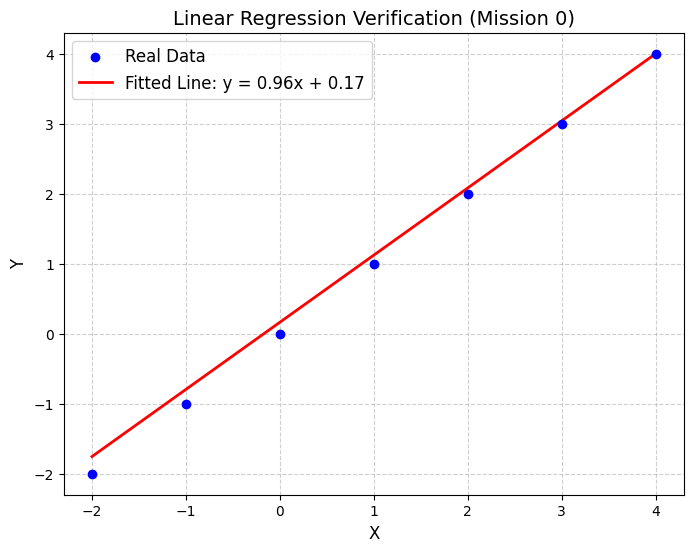

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', label='Real Data', zorder=5)
Y_fitted = a * X + b 
plt.plot(X, Y_fitted, color='red', linewidth=2, label=f'Fitted Line: y = {a:.2f}x + {b:.2f}')
plt.title('Linear Regression Verification (Mission 0)', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

在pytorch中，通常是直接使用包装好的函数，如loss.backward()用来直接计算梯度，同时，由于loss.backward()有累加效应，需要进行梯度归零
此时代码体现为
```py
loss.backward()
    with torch.no_grad(): #不影响自动微分模块
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        a.grad.zero_()
        b.grad.zero_()
```